# Chapter 11. Time Series
- Many time series are **fixed frequency**, which is to say that data points occur at regular intervals according to some rule.
> - **Timestamps:** Specific instants in time.
> - **Fixed periods:** Such as the whole month of January 2017, or the whole year 2020.
> - **Intervals of time:** Indicated by start and end timestamp. Periods can be thought of as special cases of intervals.
> - **Experiment or elapsed time:** Each timestamp is a measure of time relative to a particular start time.
- Many of the techniques can be applied to experimental time series where the **index may be an integer or floating-point number** indicating elapsed time from the start of the experiment.
- Pandas also **supports indexes based on timedeltas**, which can be a useful way of representing experiment or elaspsed time.

In [1]:
import numpy as np
import pandas as pd

In [2]:
from datetime import datetime

In [3]:
from datetime import timedelta

## 11.1 Date and Time Data Types and Tools
- Calendar-related functionality
- The ***datetime***, ***time***, and ***calendar*** modules are the main places to start.
- ***datetime*** stores both the date and time down to the microsecond.

In [4]:
now = datetime.now()
now

datetime.datetime(2022, 12, 11, 8, 28, 10, 204933)

In [5]:
now.year, now.month, now.day

(2022, 12, 11)

> - ***datetime.timedelta***, or simply ***timedelta***, represents **the temporal difference** between two datetime objects:

In [15]:
delta = datetime(2011,1,7) - datetime(2008, 6, 24, 8, 15)

In [16]:
delta

datetime.timedelta(days=926, seconds=56700)

In [19]:
delta.seconds

56700

In [21]:
start = datetime(2011, 1, 7)

In [22]:
start + timedelta(12)

datetime.datetime(2011, 1, 19, 0, 0)

> 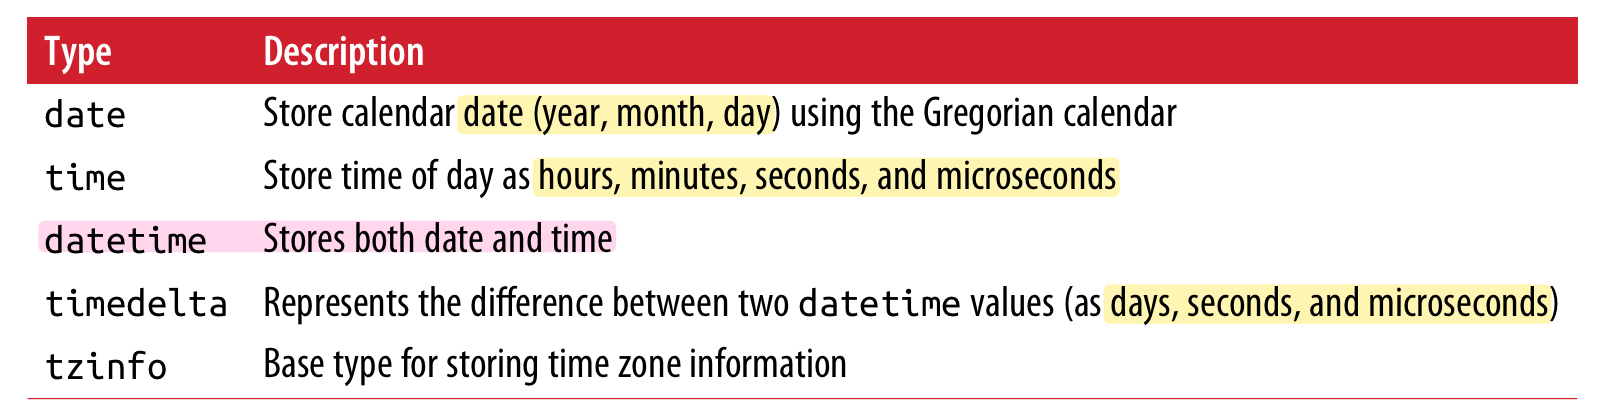

### Converting Between String and Datetime
- You can format ***datetime*** object and pandas ***Timestamp*** objects, **as string using *str*** or the ***strftime*** method
- ***datetime*** objects also have **a number of locale-specific formatting options** for systems in other countries or languages.

In [7]:
stamp = datetime(2011, 1, 3)
str(stamp)

'2011-01-03 00:00:00'

In [8]:
stamp.strftime('%Y-%m-%d')

'2011-01-03'

> 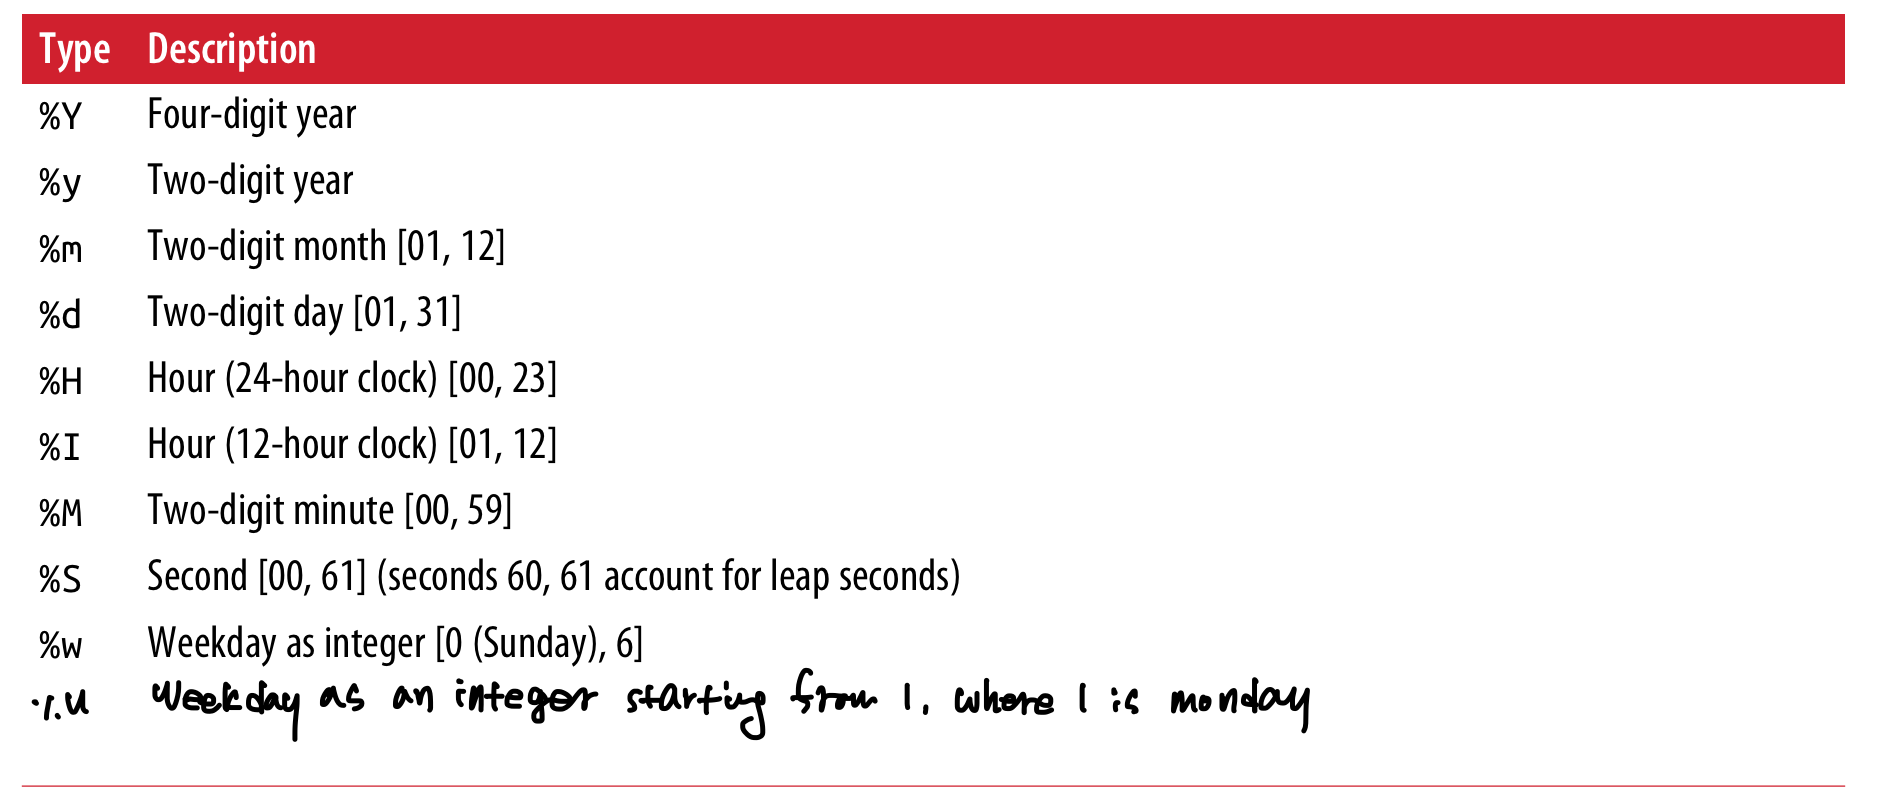
> 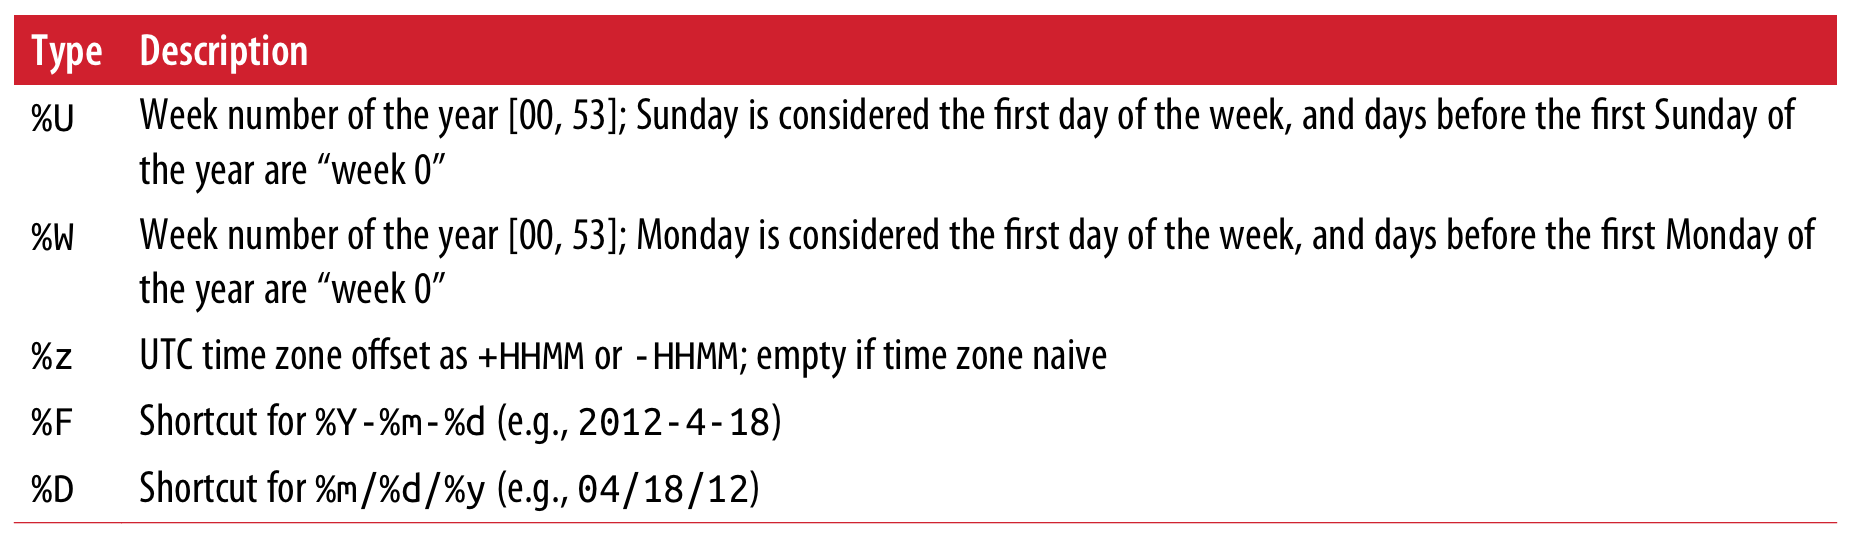

> - To convert strings to dates using ***datetime.strptime***:
> - ***datetime.strptime*** is one way to parse a date with a known format.

In [9]:
value = '2011-01-03'
datetime.strptime(value, '%Y-%m-%d')

datetime.datetime(2011, 1, 3, 0, 0)

In [7]:
datestrs = ['7/6/2011','8/6/2011']
[datetime.strptime(x, '%m/%d/%Y') for x in datestrs]

[datetime.datetime(2011, 7, 6, 0, 0), datetime.datetime(2011, 8, 6, 0, 0)]

> - The ***pandas.to_datetime*** method parses many different kinds of date representations.
> - Standard date formats like ISO8601 can be parsed quickly:

In [4]:
datestrs = ['2011-07-06 12:00:00', '2011-08-06 00:00:00']
pd.to_datetime(datestrs)

DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00'], dtype='datetime64[ns]', freq=None)

## 11.2 Time Series Basics
- A basic kind of time series object in pandas is **a Series indexed by timestamps**, which is often represented outside of pandas as **Python strings** or **datetime** objects:
- pandas stores **timestamps** using **NumPy's *datetime64 data type*** at the **nanosecond resolution**:
- *pandas.Timestamp* can store **nanosecond precision** data, while *datetime* stores only up to **microseconds**.

In [4]:
dates = [datetime(2011,1,2), datetime(2011,1,5), datetime(2011,1,7),
         datetime(2011,1,8), datetime(2011,1,10), datetime(2011,1,12)]

In [5]:
ts = pd.Series(np.random.standard_normal(6), index=dates)
ts

2011-01-02   -0.203886
2011-01-05   -0.764903
2011-01-07    0.778927
2011-01-08    0.246281
2011-01-10   -0.477490
2011-01-12   -1.729062
dtype: float64

In [6]:
ts.index

DatetimeIndex(['2011-01-02', '2011-01-05', '2011-01-07', '2011-01-08',
               '2011-01-10', '2011-01-12'],
              dtype='datetime64[ns]', freq=None)

> - Like ohter Series, **arithmetic operations** between differently indexed time series **automatically align on the dates**:

In [7]:
ts[::2]

2011-01-02   -0.203886
2011-01-07    0.778927
2011-01-10   -0.477490
dtype: float64

In [7]:
ts + ts[::2]

2011-01-02   -0.046620
2011-01-05         NaN
2011-01-07    1.784253
2011-01-08         NaN
2011-01-10   -3.285610
2011-01-12         NaN
dtype: float64

### Indexing, Selection, Subsetting
- Time series behaves like any other Series when you are indexing and selecting data based on the label.
- For longer time series, a year or only a year and month can be passed to easily select slices of data:
- Slicing produces **views on the source time series**, like slicing NumPy arrays. This means that **no data is copied**, and modifications on the slice will **be reflected in the original data**.

In [5]:
longer_ts = pd.Series(np.random.standard_normal(1000),
                      index=pd.date_range('2000-01-01', periods=1000))

In [6]:
longer_ts

2000-01-01    0.649108
2000-01-02    0.668952
2000-01-03   -0.194110
2000-01-04   -0.734730
2000-01-05   -0.359338
                ...   
2002-09-22   -0.048693
2002-09-23    0.974479
2002-09-24    0.665440
2002-09-25   -0.338658
2002-09-26    1.325943
Freq: D, Length: 1000, dtype: float64

In [8]:
# year
longer_ts['2001']

2001-01-01   -0.291724
2001-01-02   -0.237385
2001-01-03    1.850561
2001-01-04    0.092933
2001-01-05    1.560575
                ...   
2001-12-27    1.450827
2001-12-28    0.377518
2001-12-29    0.641842
2001-12-30    0.476273
2001-12-31   -0.327406
Freq: D, Length: 365, dtype: float64

In [9]:
# month
longer_ts['2001-05']

2001-05-01    1.621634
2001-05-02   -1.222135
2001-05-03   -1.867197
2001-05-04    0.107087
2001-05-05    0.359634
2001-05-06    0.843608
2001-05-07    0.431432
2001-05-08    1.761637
2001-05-09   -0.685442
2001-05-10    0.077747
2001-05-11    0.678763
2001-05-12   -0.862619
2001-05-13    1.574071
2001-05-14   -0.689319
2001-05-15   -1.894335
2001-05-16   -2.228368
2001-05-17   -1.191073
2001-05-18    1.031281
2001-05-19    0.944367
2001-05-20   -1.161639
2001-05-21    2.486195
2001-05-22    0.121316
2001-05-23    1.557370
2001-05-24    1.437197
2001-05-25    1.139773
2001-05-26   -0.819699
2001-05-27   -0.056437
2001-05-28   -1.008244
2001-05-29    1.124881
2001-05-30   -0.175579
2001-05-31   -1.914081
Freq: D, dtype: float64

> - Slicing with *datetime* objects works as well:

In [14]:
ts[datetime(2011,1,7):]

2011-01-07   -0.764858
2011-01-08    1.885756
2011-01-10   -0.824073
2011-01-12    0.736807
dtype: float64

In [15]:
ts[datetime(2011,1,7):datetime(2011,1,10)]

2011-01-07   -0.764858
2011-01-08    1.885756
2011-01-10   -0.824073
dtype: float64

> - Because most time series data is ordered chronologically, you can **slice with timestamps not contained in a time series** to perform a range query:

In [16]:
ts

2011-01-02    0.723339
2011-01-05   -2.000323
2011-01-07   -0.764858
2011-01-08    1.885756
2011-01-10   -0.824073
2011-01-12    0.736807
dtype: float64

In [17]:
ts['2011-01-06':'2011-01-11']

2011-01-07   -0.764858
2011-01-08    1.885756
2011-01-10   -0.824073
dtype: float64

> - There is an equivalent instance method, ***truncate***, that slices a Series between two dates:

In [18]:
ts.truncate(after='2011-01-09')

2011-01-02    0.723339
2011-01-05   -2.000323
2011-01-07   -0.764858
2011-01-08    1.885756
dtype: float64

### Time Series with Duplicate Indices

In [22]:
dates = pd.DatetimeIndex(['2000-01-01', '2000-01-02', '2000-01-02', '2000-01-02', '2000-01-03'])

In [24]:
dup_ts = pd.Series(np.arange(5), index=dates)
dup_ts

2000-01-01    0
2000-01-02    1
2000-01-02    2
2000-01-02    3
2000-01-03    4
dtype: int64

> - The index is not unique by **checking its *is_unique* property**:
> - Indexing into this time series will now either produces scalar values or slices, depending on **whether a timestamp is duplicated**:

In [25]:
dup_ts['2000-01-03'] # not duplicated

4

In [26]:
dup_ts['2000-01-02'] # duplicated

2000-01-02    1
2000-01-02    2
2000-01-02    3
dtype: int64

> - Suppose you wanted to aggregate the data having nonunique timestamps. One way to do is to use *groupby* and pass ***level=0*** (the one and only level

In [27]:
grouped = dup_ts.groupby(level=0)

In [28]:
grouped.mean()

2000-01-01    0.0
2000-01-02    2.0
2000-01-03    4.0
dtype: float64

In [29]:
grouped.count()

2000-01-01    1
2000-01-02    3
2000-01-03    1
dtype: int64

## 11.3 Date Ranges, Frequencies, and Shifting
- Pandas has a full suite of **standard time series frequencies** and tools for **resampling, inferring frequencies, and generating fixed-frequency date ranges**.

### Generating Date Ranges
- ***pandas.date_range*** is responsible for generating a **DatetimeIndex with an indicated length** according to particular frequency:

In [4]:
index = pd.date_range('2012-04-01', '2012-06-01')
index

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20',
               '2012-04-21', '2012-04-22', '2012-04-23', '2012-04-24',
               '2012-04-25', '2012-04-26', '2012-04-27', '2012-04-28',
               '2012-04-29', '2012-04-30', '2012-05-01', '2012-05-02',
               '2012-05-03', '2012-05-04', '2012-05-05', '2012-05-06',
               '2012-05-07', '2012-05-08', '2012-05-09', '2012-05-10',
               '2012-05-11', '2012-05-12', '2012-05-13', '2012-05-14',
               '2012-05-15', '2012-05-16', '2012-05-17', '2012-05-18',
               '2012-05-19', '2012-05-20', '2012-05-21', '2012-05-22',
               '2012-05-23', '2012-05-24', '2012-05-25', '2012-05-26',
      

- By default, *pandas.date_range* generates daily timestamps.

In [6]:
pd.date_range(start='2012-04-01', periods=20)
# = pd.date_range(end='2012-04-19', periods=20)

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20'],
              dtype='datetime64[ns]', freq='D')

In [7]:
pd.date_range('2000-01-01', '2000-12-01', freq='BM')

DatetimeIndex(['2000-01-31', '2000-02-29', '2000-03-31', '2000-04-28',
               '2000-05-31', '2000-06-30', '2000-07-31', '2000-08-31',
               '2000-09-29', '2000-10-31', '2000-11-30'],
              dtype='datetime64[ns]', freq='BM')

> 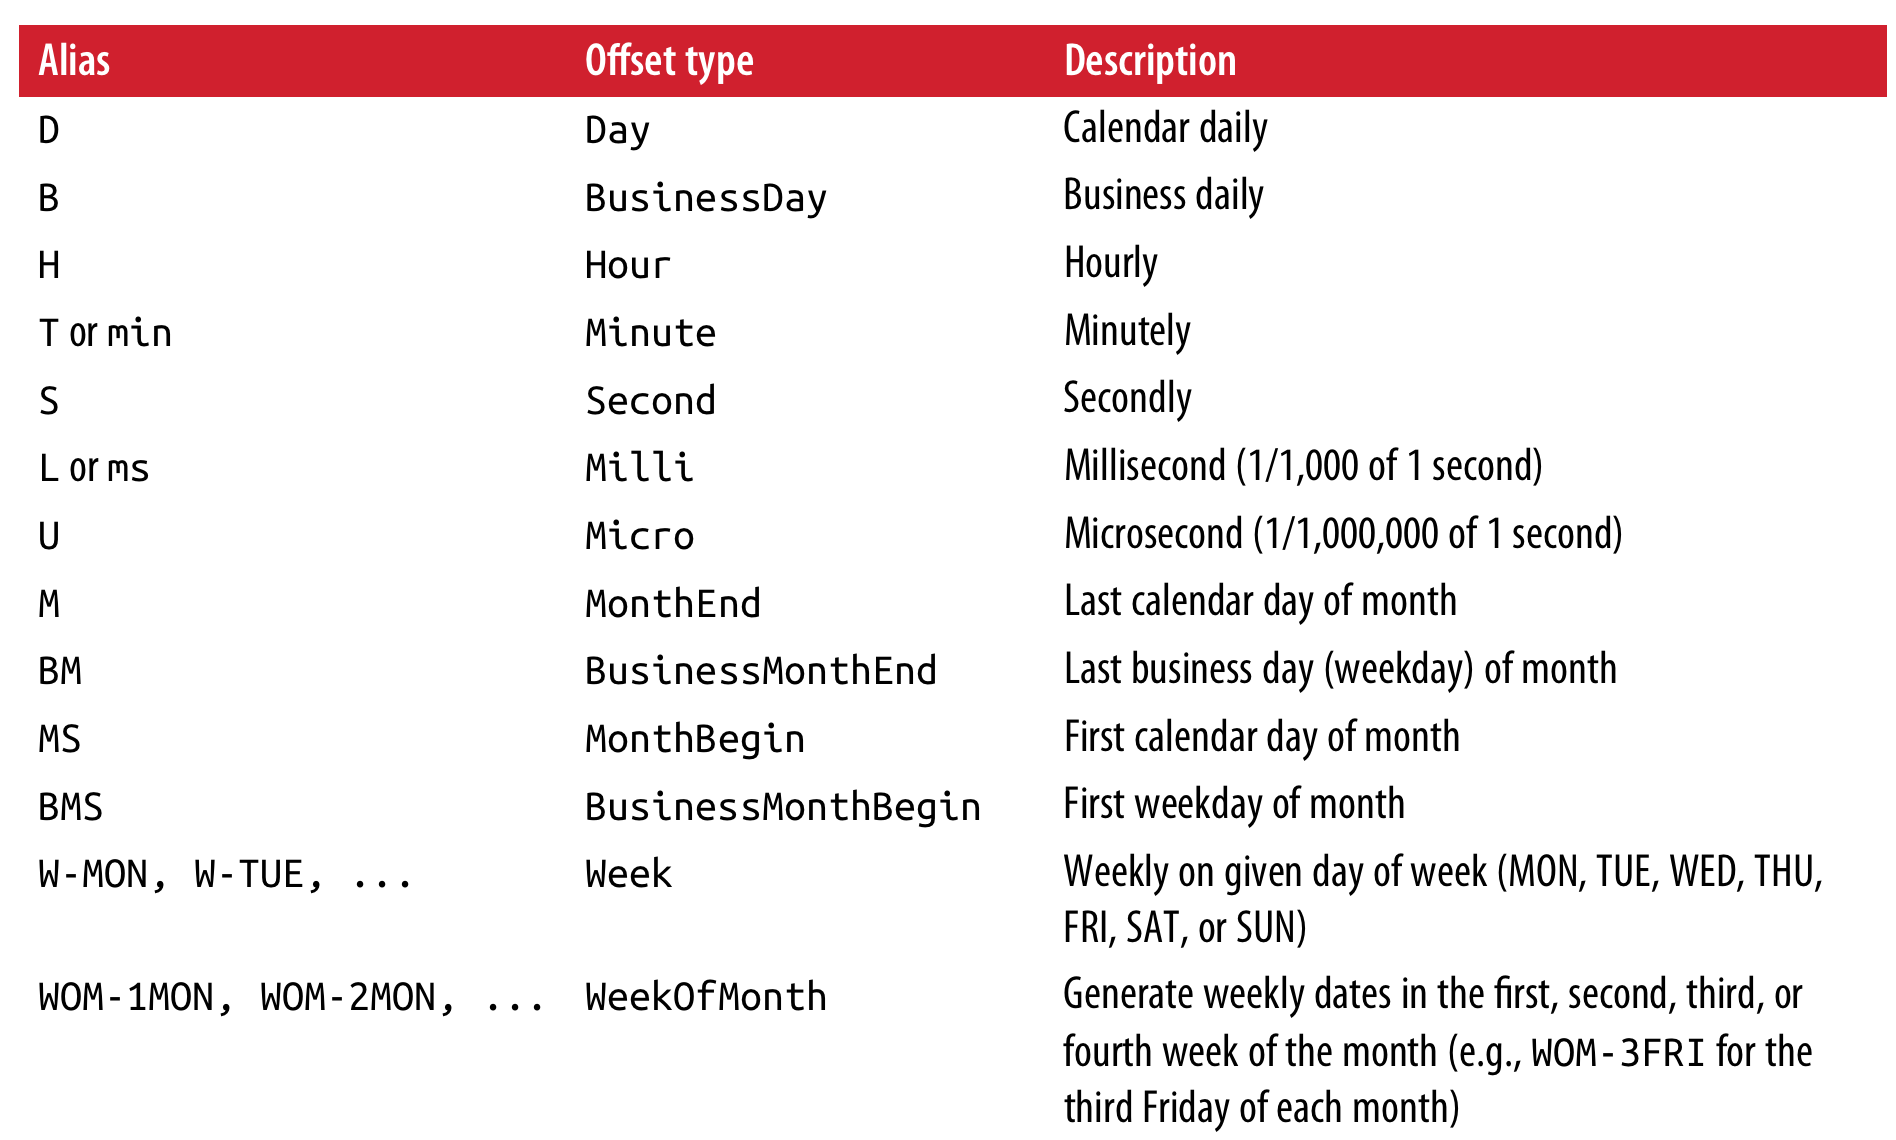

- 그 밖의 frequency에 대해서는 교재 참고!

> - pandas.date_range by default preserves the time(if any) of the start or end timestamp:

In [8]:
pd.date_range('2012-05-02 12:56:31', periods=5)

DatetimeIndex(['2012-05-02 12:56:31', '2012-05-03 12:56:31',
               '2012-05-04 12:56:31', '2012-05-05 12:56:31',
               '2012-05-06 12:56:31'],
              dtype='datetime64[ns]', freq='D')

> - To generate a set of timestamps ***normalized* to midnight as a convention**, there is a ***normalize*** option:

In [9]:
pd.date_range('2012-05-02 12:56:31', periods=5, normalize=True)

DatetimeIndex(['2012-05-02', '2012-05-03', '2012-05-04', '2012-05-05',
               '2012-05-06'],
              dtype='datetime64[ns]', freq='D')

### Frequencies and Date Offsets
- Frequencies in pandas are composed of a **base frequency and a multiplier**.
- For each base frequency, there is an object referred to as a ***date offset***:

In [4]:
from pandas.tseries.offsets import Hour, Minute

In [5]:
hour = Hour()

> - You can define a multiple of an offset by passing an integer:

In [7]:
four_hours = Hour(4)

In [8]:
four_hours

<4 * Hours>

> - In most applications, you would never to explicitly create one of these objects; **instead you'd use a string alias like "H" or "4H"**.

In [9]:
pd.date_range('2000-01-01', '2000-01-03 23:59', freq='4H')

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 04:00:00',
               '2000-01-01 08:00:00', '2000-01-01 12:00:00',
               '2000-01-01 16:00:00', '2000-01-01 20:00:00',
               '2000-01-02 00:00:00', '2000-01-02 04:00:00',
               '2000-01-02 08:00:00', '2000-01-02 12:00:00',
               '2000-01-02 16:00:00', '2000-01-02 20:00:00',
               '2000-01-03 00:00:00', '2000-01-03 04:00:00',
               '2000-01-03 08:00:00', '2000-01-03 12:00:00',
               '2000-01-03 16:00:00', '2000-01-03 20:00:00'],
              dtype='datetime64[ns]', freq='4H')

> - **Many offset can be combined by addition**:
> - Similarly, you can pass frequency strings, like "1h30min"
> - Users can define their **own custom frequency classes** to provide date logic not available in pandas.

In [10]:
pd.date_range('2000-01-01', periods=10, freq="1h30min")

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 01:30:00',
               '2000-01-01 03:00:00', '2000-01-01 04:30:00',
               '2000-01-01 06:00:00', '2000-01-01 07:30:00',
               '2000-01-01 09:00:00', '2000-01-01 10:30:00',
               '2000-01-01 12:00:00', '2000-01-01 13:30:00'],
              dtype='datetime64[ns]', freq='90T')

> - One useful frequency class is **"week of month,"** starting with ***WOM***. This enables you to get dates like the third Friday of each month:

In [10]:
monthly_dates = pd.date_range("2012-01-01", "2012-09-01", freq='WOM-3FRI')
list(monthly_dates)

[Timestamp('2012-01-20 00:00:00', freq='WOM-3FRI'),
 Timestamp('2012-02-17 00:00:00', freq='WOM-3FRI'),
 Timestamp('2012-03-16 00:00:00', freq='WOM-3FRI'),
 Timestamp('2012-04-20 00:00:00', freq='WOM-3FRI'),
 Timestamp('2012-05-18 00:00:00', freq='WOM-3FRI'),
 Timestamp('2012-06-15 00:00:00', freq='WOM-3FRI'),
 Timestamp('2012-07-20 00:00:00', freq='WOM-3FRI'),
 Timestamp('2012-08-17 00:00:00', freq='WOM-3FRI')]

### Shifting (Leading and Lagging) Data
- ***Shifting*** refers to **moving data backward and forward through time**.
- Both Series and DataFrame have a ***shift*** method for doing naive shifts forward or backward, **leaving the index unmodified**:

In [5]:
ts = pd.Series(np.random.standard_normal(4), 
               index=pd.date_range('2000-01-01', periods=4, freq='M'))

In [6]:
ts

2000-01-31    0.146756
2000-02-29   -2.592823
2000-03-31   -1.904570
2000-04-30   -0.460857
Freq: M, dtype: float64

In [7]:
ts.shift(2)

2000-01-31         NaN
2000-02-29         NaN
2000-03-31    0.146756
2000-04-30   -2.592823
Freq: M, dtype: float64

> - A common use of ***shift*** is computing consecutive percent changes in a time series or multiple time series as DataFrame columns.

In [8]:
ts/ts.shift(2)

2000-01-31          NaN
2000-02-29          NaN
2000-03-31   -12.977781
2000-04-30     0.177743
Freq: M, dtype: float64

> - **If the frequency is known**, it can be passed to *shift* to advance the timestamps **instead of simply the data**:

In [9]:
ts.shift(2, freq='M')

2000-03-31    0.146756
2000-04-30   -2.592823
2000-05-31   -1.904570
2000-06-30   -0.460857
Freq: M, dtype: float64

> - Other frequencies can be passed, too, giving you some flexibility in how to lead and lag data:

In [10]:
ts.shift(3, freq='D')

2000-02-03    0.146756
2000-03-03   -2.592823
2000-04-03   -1.904570
2000-05-03   -0.460857
dtype: float64

In [11]:
ts.shift(1, freq='90T')
# The "T" here stands for minutes

2000-01-31 01:30:00    0.146756
2000-02-29 01:30:00   -2.592823
2000-03-31 01:30:00   -1.904570
2000-04-30 01:30:00   -0.460857
dtype: float64

- Note that the ***freq* parameter here indicates the offset to apply to the timestamps, but it does not change the underlying frequency of the data**, if any.

### Shifting dates with offsets
- The pandas date offsets can also be used with *datetime* or *Timestamp* objects:

In [4]:
from pandas.tseries.offsets import Day, MonthEnd

In [5]:
now = datetime(2011,11,17)
now + 3*Day()

Timestamp('2011-11-20 00:00:00')

> - If you add an anchored offset like ***MonthEnd***, the **first increment will "roll forward" a date to the next date according to the frequency rule**:
> - Anchored offsets can explicity "roll" dates forward or backward by simply using their ***rollforward*** and ***rollback*** method, repectively:

In [6]:
now + MonthEnd()

Timestamp('2011-11-30 00:00:00')

In [7]:
now + MonthEnd(2)

Timestamp('2011-12-31 00:00:00')

In [8]:
offset = MonthEnd()
offset.rollforward(now)

Timestamp('2011-11-30 00:00:00')

In [9]:
offset.rollback(now)

Timestamp('2011-10-31 00:00:00')

> - A creative use of date offsets is to use these methods with ***groupby***:

In [11]:
ts = pd.Series(np.random.standard_normal(20),
               index=pd.date_range('2000-01-15', periods=20, freq='4D'))
ts

2000-01-15   -0.512482
2000-01-19   -0.483087
2000-01-23   -0.274530
2000-01-27    0.655866
2000-01-31    1.576231
2000-02-04   -0.409542
2000-02-08   -0.658545
2000-02-12   -0.844406
2000-02-16    2.685531
2000-02-20   -2.224031
2000-02-24    0.493680
2000-02-28    0.324692
2000-03-03   -0.232430
2000-03-07    0.366267
2000-03-11    0.673354
2000-03-15   -0.020302
2000-03-19    1.833233
2000-03-23   -0.665588
2000-03-27    0.814125
2000-03-31    0.666977
Freq: 4D, dtype: float64

In [13]:
ts.groupby(MonthEnd().rollforward).mean()
# = ts.resample('M').mean() , an easier and faster way

2000-01-31    0.192399
2000-02-29   -0.090374
2000-03-31    0.429454
dtype: float64

## 11.4 Time Zone Handling

In [1]:
import pytz

In [5]:
pytz.common_timezones[-5:]

['US/Eastern', 'US/Hawaii', 'US/Mountain', 'US/Pacific', 'UTC']

In [7]:
tz = pytz.timezone('America/New_York')
tz

<DstTzInfo 'America/New_York' LMT-1 day, 19:04:00 STD>

### Time Zone Localization and Conversion
- By default, time series in pandas are ***time zone naive***

In [8]:
dates = pd.date_range('2012-03-09 09:30', periods=6)

- Date range can be generated with a time zone set:
    - pd.date_range('2012-03-09 09:30, periods=6, tz='UTC')

In [9]:
ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)
ts

2012-03-09 09:30:00   -0.089318
2012-03-10 09:30:00   -1.098145
2012-03-11 09:30:00   -1.633800
2012-03-12 09:30:00    0.053868
2012-03-13 09:30:00   -0.139456
2012-03-14 09:30:00   -0.250665
Freq: D, dtype: float64

In [16]:
print(ts.index.tz)

None


> - **Conversion from naive to localized**(reinterpreted as having been observed in a particular time zone) is hadled by the ***tz_localize*** method:

In [11]:
ts_utc = ts.tz_localize('UTC')
ts_utc

2012-03-09 09:30:00+00:00   -0.089318
2012-03-10 09:30:00+00:00   -1.098145
2012-03-11 09:30:00+00:00   -1.633800
2012-03-12 09:30:00+00:00    0.053868
2012-03-13 09:30:00+00:00   -0.139456
2012-03-14 09:30:00+00:00   -0.250665
Freq: D, dtype: float64

In [12]:
ts_utc.index

DatetimeIndex(['2012-03-09 09:30:00+00:00', '2012-03-10 09:30:00+00:00',
               '2012-03-11 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='D')

In [14]:
print(ts_utc.index.tz)

UTC


> - Once a time series has been localized to a particular time zone, it can be **converted to another time zone with *tz_convert***:

In [21]:
ts_utc.tz_convert('America/New_York')

2012-03-09 04:30:00-05:00   -0.089318
2012-03-10 04:30:00-05:00   -1.098145
2012-03-11 05:30:00-04:00   -1.633800
2012-03-12 05:30:00-04:00    0.053868
2012-03-13 05:30:00-04:00   -0.139456
2012-03-14 05:30:00-04:00   -0.250665
Freq: D, dtype: float64

> - ***tz_localize*** and ***tz_convert*** are also instance methods on **DatetimeIndex**:

In [27]:
ts.index.tz_localize('Asia/Shanghai')

DatetimeIndex(['2012-03-09 09:30:00+08:00', '2012-03-10 09:30:00+08:00',
               '2012-03-11 09:30:00+08:00', '2012-03-12 09:30:00+08:00',
               '2012-03-13 09:30:00+08:00', '2012-03-14 09:30:00+08:00'],
              dtype='datetime64[ns, Asia/Shanghai]', freq=None)

### 이 후 소챕터 Skip

## 11.5 Periods and Period Arithmetic

In [28]:
p = pd.Period('2011', freq='A-DEC')
p

Period('2011', 'A-DEC')

- The ***period* object** represents the full time span from January 1, 2011, to December 31, 2011, inclusive.

> - Conveniently, adding and subtracting **integers** from periods has the effect of **shitting their frequency**:

In [29]:
p + 5 

Period('2016', 'A-DEC')

> - If two periods have the same frequency, their difference is **the number of units between them as a date offset**:

In [30]:
pd.Period('2014', freq='A-DEC') - p

<3 * YearEnds: month=12>

> - Regular ranges of periods can be constructed with the ***period_range*** function:

In [32]:
periods = pd.period_range('2000-01-01', '2000-06-30', freq="M")
periods

PeriodIndex(['2000-01', '2000-02', '2000-03', '2000-04', '2000-05', '2000-06'], dtype='period[M]')

In [33]:
pd.Series(np.random.standard_normal(6), index=periods)

2000-01    0.704364
2000-02    0.054573
2000-03    0.271326
2000-04   -3.354468
2000-05   -0.360463
2000-06    0.107946
Freq: M, dtype: float64

> - If you have an **array of strings**, you can also use the ***PeriodIndex*** class, where all of its values are periods:

In [37]:
values = ['2001Q3','2002Q2','2003Q1']
index = pd.PeriodIndex(values, freq='Q-DEC')

In [38]:
index

PeriodIndex(['2001Q3', '2002Q2', '2003Q1'], dtype='period[Q-DEC]')

### Period Frequency Conversion
- Periods and PeriodIndex objects can be converted to another frequency with their ***asfreq* method**.

In [4]:
p = pd.Period('2011', freq='A-DEC')
p

Period('2011', 'A-DEC')

In [5]:
p.asfreq('M', how='start')

Period('2011-01', 'M')

In [6]:
p.asfreq('M', how='end')

Period('2011-12', 'M')

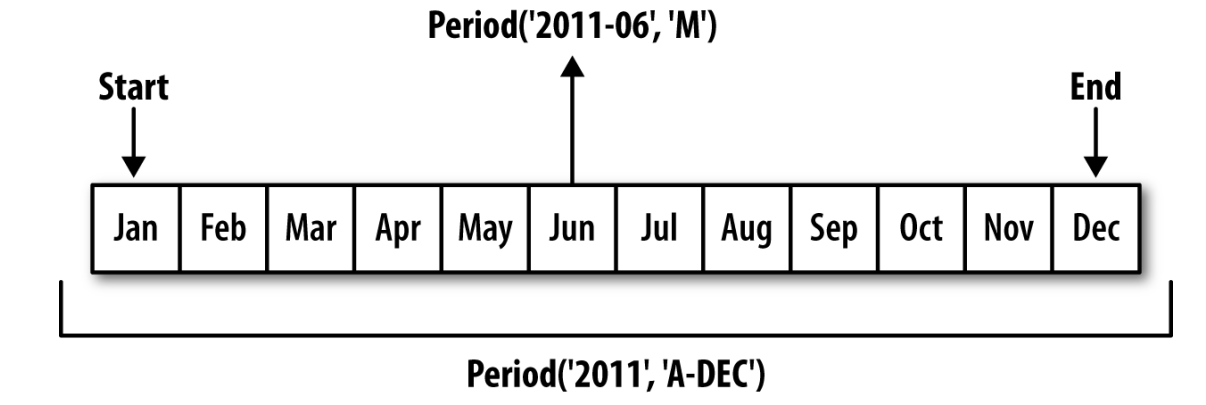

> - When you are **converting from high to low frequency**, pandas determines the subperiod, depending on **where the superperiod "belongs**."

In [10]:
p = pd.Period('Aug-2011', 'M') # High frequency
p.asfreq('A-Jun') # Low frequency로 전환

Period('2012', 'A-JUN')

> - Whole PeriodIndex objects or time series can be similarly converted with the same semantics:

In [11]:
periods = pd.period_range('2006','2009', freq='A-DEC')

In [13]:
ts = pd.Series(np.random.standard_normal(len(periods)), index=periods)
ts

2006    1.122656
2007    0.458354
2008    2.611787
2009   -0.837338
Freq: A-DEC, dtype: float64

In [14]:
ts.asfreq('M', how='start')

2006-01    1.122656
2007-01    0.458354
2008-01    2.611787
2009-01   -0.837338
Freq: M, dtype: float64

- Here, the annual periods are replaced with monthly periods corresponding to **the first month falling within each annual period**.

> - If we instead wanted **the last business day of each year**, we can use the **"B" frequency** and indicated that we want the **end of the period**:

In [15]:
ts.asfreq('B', how='end')

2006-12-29    1.122656
2007-12-31    0.458354
2008-12-31    2.611787
2009-12-31   -0.837338
Freq: B, dtype: float64

### Quarterly Period Frequncies

In [4]:
p = pd.Period('2012Q4', freq='Q-JAN')
p

Period('2012Q4', 'Q-JAN')

- In the case of a **fiscal year ending in January**, 2012Q4 runs from November 2011 through January 2012, which you can check by converting to daily frequency:

In [5]:
p.asfreq('D', how='start')

Period('2011-11-01', 'D')

In [6]:
p.asfreq('D', how='end')

Period('2012-01-31', 'D')

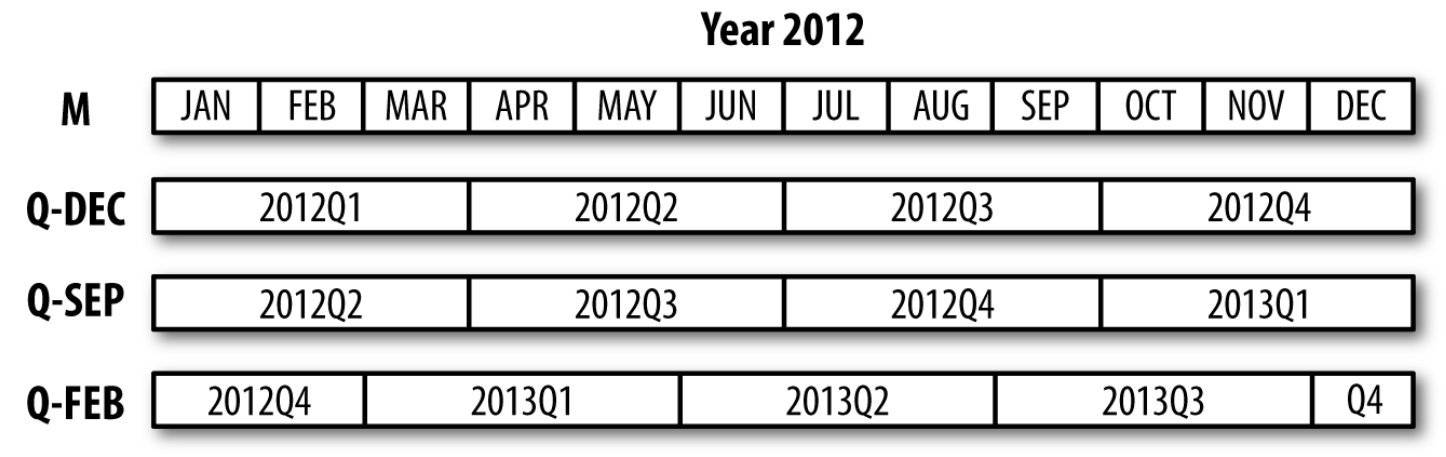

In [9]:
p4m = (p.asfreq('B', how='end')-1).asfreq('T', how='start')+16*60
p4m

Period('2012-01-30 16:00', 'T')

> - The ***to_timestamp*** method returns the **Timestamp at the start of the period by defalut**

In [11]:
p4m.to_timestamp()

Timestamp('2012-01-30 16:00:00')

> - Quarterly range can be generated using ***pandas.period_range***.

In [14]:
periods = pd.period_range('2011Q3', '2012Q4', freq='Q-JAN')
ts = pd.Series(np.arange(len(periods)), index=periods)
ts

2011Q3    0
2011Q4    1
2012Q1    2
2012Q2    3
2012Q3    4
2012Q4    5
Freq: Q-JAN, dtype: int64

In [15]:
new_periods = (periods.asfreq('B', how='end')-1).asfreq('H', 'start')+16
ts.index = new_periods.to_timestamp()
ts

2010-10-28 16:00:00    0
2011-01-28 16:00:00    1
2011-04-28 16:00:00    2
2011-07-28 16:00:00    3
2011-10-28 16:00:00    4
2012-01-30 16:00:00    5
dtype: int64

### Converting Timestamp to Periods (and Back)
- Series and DataFrame obgects indexed by **timestamps can be converted to periods with *to_period* method**.

In [19]:
dates = pd.date_range('2000-01-01', periods=3, freq='M')
ts = pd.Series(np.random.standard_normal(3), index=dates)
ts

2000-01-31   -0.395043
2000-02-29   -1.695739
2000-03-31   -0.229253
Freq: M, dtype: float64

In [22]:
pts = ts.to_period()
pts

2000-01   -0.395043
2000-02   -1.695739
2000-03   -0.229253
Freq: M, dtype: float64

> - While the frequncy of the **new PeriodIndex is inferred from the timestamps by defalut**, you can specify any supported frequncy.
> - There is also **no problem with having duplicate periods** in the result:

In [28]:
dates = pd.date_range('2000-01-29', periods=6)
ts2 = pd.Series(np.random.standard_normal(6), index=dates)
ts2 # timestamp

2000-01-29    1.126038
2000-01-30    0.267997
2000-01-31    1.078600
2000-02-01   -1.250439
2000-02-02    1.559407
2000-02-03    0.251444
Freq: D, dtype: float64

In [30]:
ts2.to_period('M') # period('M') : 'M' freq로 변경

2000-01    1.126038
2000-01    0.267997
2000-01    1.078600
2000-02   -1.250439
2000-02    1.559407
2000-02    0.251444
Freq: M, dtype: float64

> - To convert **back to timestamps, use the *to_timestamp* method**, which returns a *DatetimeIndex*:

In [32]:
pts = ts2.to_period()
pts # period(D) : 기존 시리즈와 freq 동일

2000-01-29    1.126038
2000-01-30    0.267997
2000-01-31    1.078600
2000-02-01   -1.250439
2000-02-02    1.559407
2000-02-03    0.251444
Freq: D, dtype: float64

In [34]:
pts.to_timestamp(how='end') # timestampe

2000-01-29 23:59:59.999999999    1.126038
2000-01-30 23:59:59.999999999    0.267997
2000-01-31 23:59:59.999999999    1.078600
2000-02-01 23:59:59.999999999   -1.250439
2000-02-02 23:59:59.999999999    1.559407
2000-02-03 23:59:59.999999999    0.251444
Freq: D, dtype: float64

### Creating a Periodindex from Arrays
- Fixed frequency datasets are sometimes stored **with time span information spread across multiple columns**.

In [4]:
data = pd.read_csv('Examples/macrodata.csv')
data.head(5)

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


> - By passing these arrays to ***PeriodIndex*** with a frequency, you can **combine them to form an index for the DataFrame**:

In [6]:
index = pd.PeriodIndex(year=data['year'], quarter=data['quarter'],
                       freq='Q-DEC')
index

PeriodIndex(['1959Q1', '1959Q2', '1959Q3', '1959Q4', '1960Q1', '1960Q2',
             '1960Q3', '1960Q4', '1961Q1', '1961Q2',
             ...
             '2007Q2', '2007Q3', '2007Q4', '2008Q1', '2008Q2', '2008Q3',
             '2008Q4', '2009Q1', '2009Q2', '2009Q3'],
            dtype='period[Q-DEC]', length=203)

In [7]:
data.index = index
data['infl']

1959Q1    0.00
1959Q2    2.34
1959Q3    2.74
1959Q4    0.27
1960Q1    2.31
          ... 
2008Q3   -3.16
2008Q4   -8.79
2009Q1    0.94
2009Q2    3.37
2009Q3    3.56
Freq: Q-DEC, Name: infl, Length: 203, dtype: float64

## 11.6 Resampling and Frequency Conversion
- Aggregating **higher frequency data to lower frequency** is called ***downsampling***, while converting **lower frequency to higher frequncy** is called ***upsampling***.
- The ***resample*** method has a **similar API to *groupby***; you call *resample* to group data, **then call an aggregation function**:

In [12]:
dates = pd.date_range('2000-01-01', periods=100)
ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)
ts

2000-01-01    0.625534
2000-01-02   -2.066063
2000-01-03    1.789245
2000-01-04    1.771609
2000-01-05    0.406342
                ...   
2000-04-05   -0.845734
2000-04-06    1.678810
2000-04-07   -0.778044
2000-04-08    0.677013
2000-04-09    0.082202
Freq: D, Length: 100, dtype: float64

In [13]:
ts.resample('M').mean() #'M': last calendar day of month

2000-01-31    0.258969
2000-02-29   -0.019566
2000-03-31    0.099410
2000-04-30    0.047483
Freq: M, dtype: float64

In [14]:
ts.resample('M', kind='period').mean()

2000-01    0.258969
2000-02   -0.019566
2000-03    0.099410
2000-04    0.047483
Freq: M, dtype: float64

> 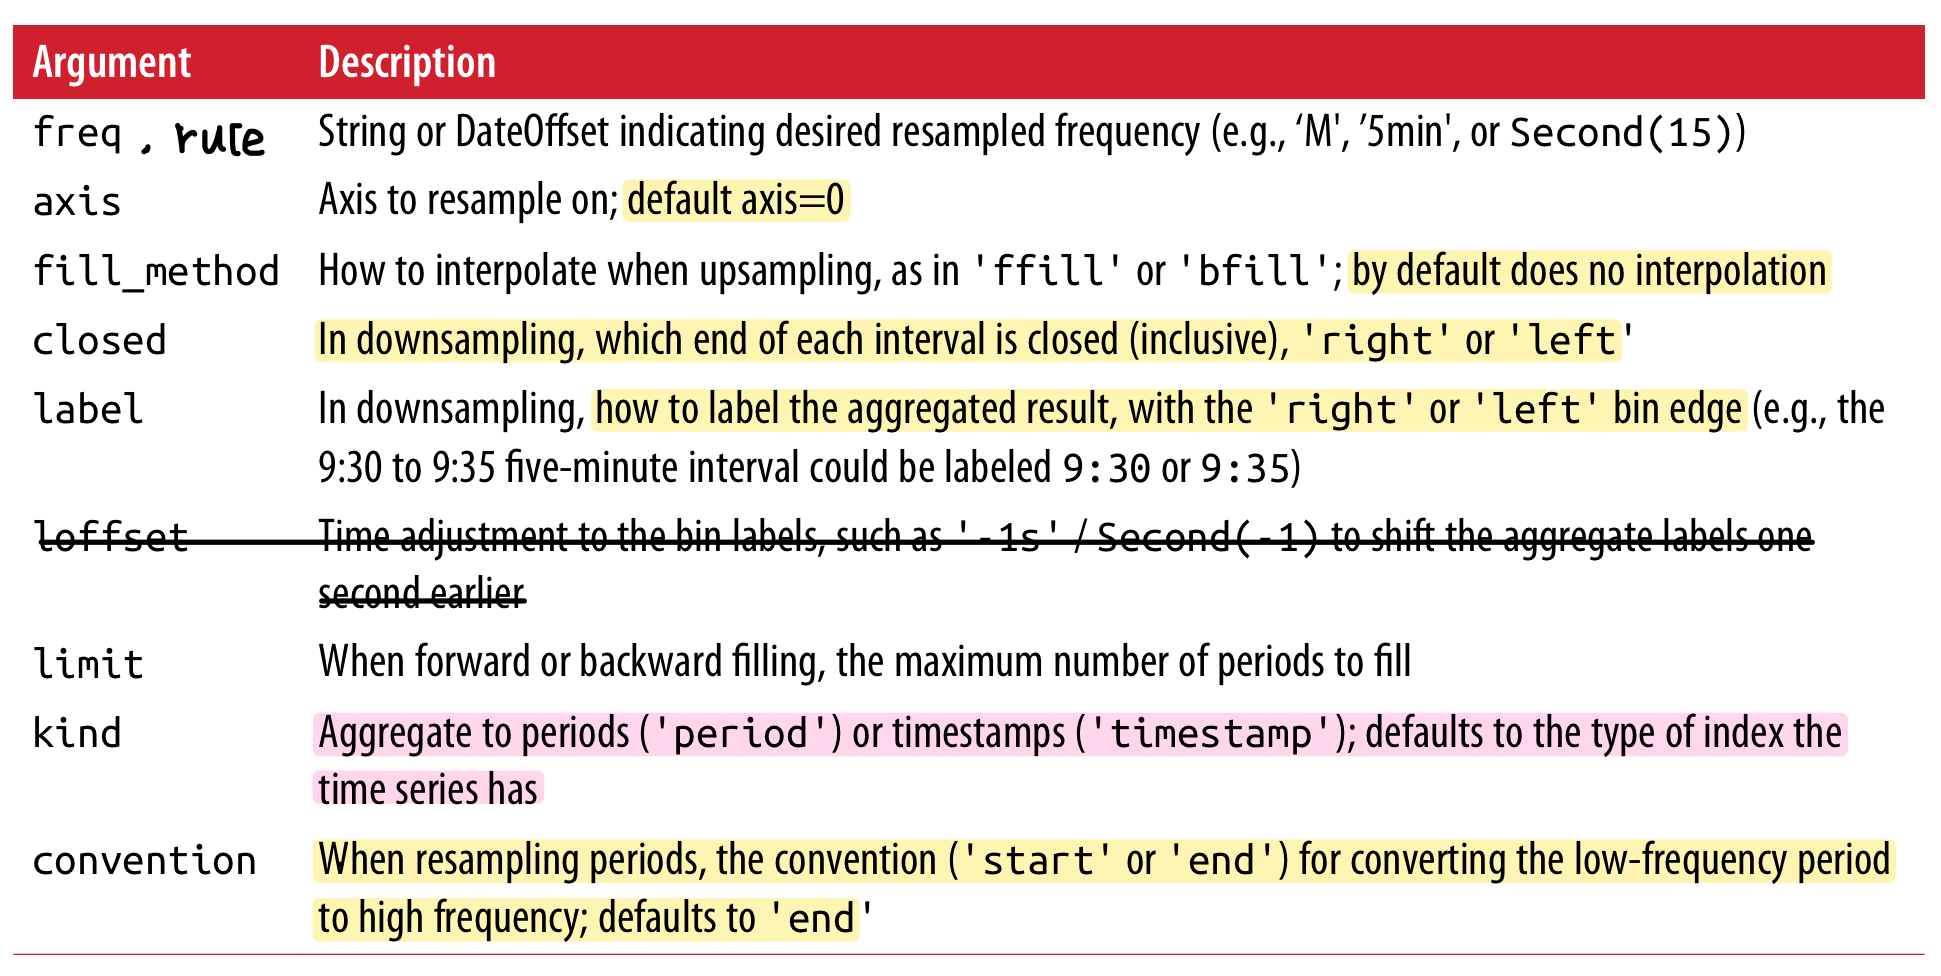

### Downsampling
- Higher -> lower frequency
- The data you're aggregating **doesn't need to be fixed freqeuntly**.
- The desired frequency defines ***bin edges*** that are used to slice the time series into pieces to aggregate.
- There are a couple things to think about when using ***resample*** to downsample data:
 > 1. **Which side of each interval is closed**
 > 2. **How to label each aggregated bin, either with the start of the interval or the end** 

In [4]:
dates = pd.date_range('2000-01-01', periods=12, freq='T')
ts = pd.Series(np.arange(len(dates)), index=dates)
ts

2000-01-01 00:00:00     0
2000-01-01 00:01:00     1
2000-01-01 00:02:00     2
2000-01-01 00:03:00     3
2000-01-01 00:04:00     4
2000-01-01 00:05:00     5
2000-01-01 00:06:00     6
2000-01-01 00:07:00     7
2000-01-01 00:08:00     8
2000-01-01 00:09:00     9
2000-01-01 00:10:00    10
2000-01-01 00:11:00    11
Freq: T, dtype: int64

In [5]:
ts.resample('5min').sum()

2000-01-01 00:00:00    10
2000-01-01 00:05:00    35
2000-01-01 00:10:00    21
Freq: 5T, dtype: int64

- The freqency you pass defines bin edge in five-minute increments. For this frequency, **by default the *left* bin edge is inclusive**.

In [6]:
ts.resample('5min', closed='right').sum()

1999-12-31 23:55:00     0
2000-01-01 00:00:00    15
2000-01-01 00:05:00    40
2000-01-01 00:10:00    11
Freq: 5T, dtype: int64

In [7]:
ts.resample('5min', closed='right', label='right').sum()

2000-01-01 00:00:00     0
2000-01-01 00:05:00    15
2000-01-01 00:10:00    40
2000-01-01 00:15:00    11
Freq: 5T, dtype: int64

> 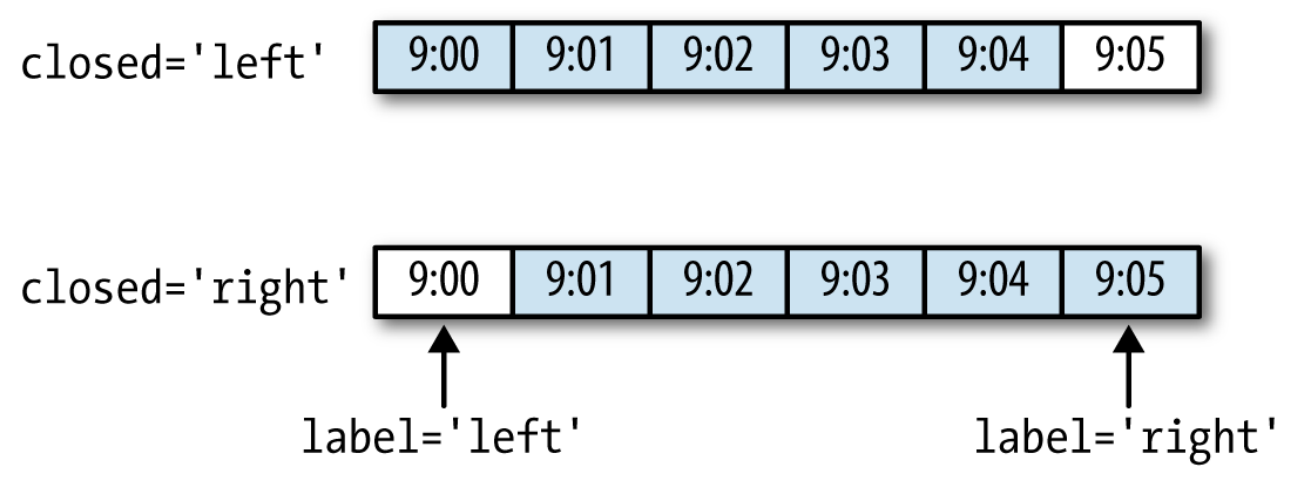

In [11]:
from pandas.tseries.frequencies import to_offset

In [16]:
result = ts.resample('5min', closed='right', label='right').sum()

In [19]:
result.index = result.index + to_offset('-1s')
result

1999-12-31 23:59:58     0
2000-01-01 00:04:58    15
2000-01-01 00:09:58    40
2000-01-01 00:14:58    11
Freq: 5T, dtype: int64

### Open-high-low-close (OHLC) resampling
- One popular way to aggregate a time series is to compute four values for each bucket:
    **the first (open), last (close), maximum (high), and minimum (low) values**

In [21]:
ts = pd.Series(np.random.permutation(np.arange(len(dates))), index=dates)
ts

2000-01-01 00:00:00     3
2000-01-01 00:01:00     8
2000-01-01 00:02:00     6
2000-01-01 00:03:00    10
2000-01-01 00:04:00     2
2000-01-01 00:05:00     5
2000-01-01 00:06:00     0
2000-01-01 00:07:00     4
2000-01-01 00:08:00     9
2000-01-01 00:09:00    11
2000-01-01 00:10:00     1
2000-01-01 00:11:00     7
Freq: T, dtype: int64

In [22]:
ts.resample('5min').ohlc()

,open,high,low,close
2000-01-01 00:00:00,3,10,2,2
2000-01-01 00:05:00,5,11,0,11
2000-01-01 00:10:00,1,7,1,7


### Upsampling and Interpolation
- Converting **from a lower frequency to a higher frequency**, where no aggregation is needed.

In [25]:
frame = pd.DataFrame(np.random.standard_normal((2,4)),
                     index=pd.date_range('2000-01-01', periods=2, freq='W-WED'),
                     columns=['Colorado','Texas','New York','Ohio'])
frame

,Colorado,Texas,New York,Ohio
2000-01-05,-0.478499,0.487380,-0.588085,-0.987739
2000-01-12,-1.166163,-1.592917,0.476405,-0.622902


> - To convert to the **higher frequency without any aggregation, use the *asfreq* method**:

In [26]:
df_daily = frame.resample('D').asfreq()
df_daily

,Colorado,Texas,New York,Ohio
2000-01-05,-0.478499,0.487380,-0.588085,-0.987739
2000-01-06,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,-1.166163,-1.592917,0.476405,-0.622902


In [39]:
frame.resample('D').ffill(limit=2)

,Colorado,Texas,New York,Ohio
2000-01-05,-0.478499,0.487380,-0.588085,-0.987739
2000-01-06,-0.478499,0.487380,-0.588085,-0.987739
2000-01-07,-0.478499,0.487380,-0.588085,-0.987739
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,-1.166163,-1.592917,0.476405,-0.622902


In [41]:
frame.resample('W-THU').ffill()

,Colorado,Texas,New York,Ohio
2000-01-06,-0.478499,0.487380,-0.588085,-0.987739
2000-01-13,-1.166163,-1.592917,0.476405,-0.622902


### Resampling with Periods
- Resampling data indexed by periods is similar to timestamp:

In [4]:
frame = pd.DataFrame(np.random.standard_normal((24,4)),
                     index=pd.period_range('1-2000','12-2001', freq='M'),
                     columns=['Colorado','Texas','New York','Ohio'])
frame.head()

,Colorado,Texas,New York,Ohio
2000-01,-0.172596,0.929151,-1.172467,0.579314
2000-02,0.719950,-0.248475,-0.225702,-0.170793
2000-03,-0.411147,-0.122329,-1.430516,0.399932
2000-04,-0.769784,-2.474728,-1.290507,0.436561
2000-05,-1.134167,-0.967319,0.577894,-0.128218


In [8]:
annual_frame = frame.resample('A-DEC').mean() # Downsampling
annual_frame

,Colorado,Texas,New York,Ohio
2000,0.121340,-0.080805,-0.452251,-0.158288
2001,0.025256,-0.023321,-0.098036,0.064480


> - Before "Upsampling periods", you must make a decision about **which end of the time span in the new frequency to place the values**.
> - The ***convention*** argument **defaults to 'start' but can also be 'end'**:

In [9]:
annual_frame.resample('Q-DEC').ffill() # upsampling

,Colorado,Texas,New York,Ohio
2000Q1,0.121340,-0.080805,-0.452251,-0.158288
2000Q2,0.121340,-0.080805,-0.452251,-0.158288
2000Q3,0.121340,-0.080805,-0.452251,-0.158288
2000Q4,0.121340,-0.080805,-0.452251,-0.158288
2001Q1,0.025256,-0.023321,-0.098036,0.064480
2001Q2,0.025256,-0.023321,-0.098036,0.064480
2001Q3,0.025256,-0.023321,-0.098036,0.064480
2001Q4,0.025256,-0.023321,-0.098036,0.064480


In [13]:
annual_frame.resample('Q-DEC', convention='end').asfreq()

,Colorado,Texas,New York,Ohio
2000Q4,0.121340,-0.080805,-0.452251,-0.158288
2001Q1,NaN,NaN,NaN,NaN
2001Q2,NaN,NaN,NaN,NaN
2001Q3,NaN,NaN,NaN,NaN
2001Q4,0.025256,-0.023321,-0.098036,0.064480


### Grouped Time Resampling
- For time series data, the ***resample*** method is semantically **a group operatioin based on a time intervalization**:

In [14]:
N = 15

In [15]:
times = pd.date_range('2017-05-20 00:00', freq='1min', periods=N)

In [16]:
df = pd.DataFrame({'time':times, 'value':np.arange(N)})
df

,time,value
0,2017-05-20 00:00:00,0
1,2017-05-20 00:01:00,1
2,2017-05-20 00:02:00,2
3,2017-05-20 00:03:00,3
4,2017-05-20 00:04:00,4
5,2017-05-20 00:05:00,5
6,2017-05-20 00:06:00,6
7,2017-05-20 00:07:00,7
8,2017-05-20 00:08:00,8
9,2017-05-20 00:09:00,9


> - Here, we can index by 'time' and then resample:

In [18]:
df.set_index('time').resample('5min').count()

,value
time,
2017-05-20 00:00:00,5
2017-05-20 00:05:00,5
2017-05-20 00:10:00,5


In [20]:
df2 = pd.DataFrame({'time':times.repeat(3),
                    'key':np.tile(['a','b','c'], N),
                    'value':np.arange(N*3)})
df2.head(7)

,time,key,value
0,2017-05-20 00:00:00,a,0
1,2017-05-20 00:00:00,b,1
2,2017-05-20 00:00:00,c,2
3,2017-05-20 00:01:00,a,3
4,2017-05-20 00:01:00,b,4
5,2017-05-20 00:01:00,c,5
6,2017-05-20 00:02:00,a,6


> - To do the resampling for each value of 'key', we introduce the ***pandas.Grouper*** object:
> - One constraint with using pandas.Grouper is that the time must be the index of the Series or DataFrame.

In [21]:
time_key = pd.Grouper(freq='5min')

> - We can then set the time index, group by 'key' and 'time_key', and aggregate:

In [27]:
resampled = df2.set_index('time').groupby(['key', time_key]).sum()
resampled

value
key time                      
a   2017-05-20 00:00:00     30
    2017-05-20 00:05:00    105
    2017-05-20 00:10:00    180
b   2017-05-20 00:00:00     35
    2017-05-20 00:05:00    110
    2017-05-20 00:10:00    185
c   2017-05-20 00:00:00     40
    2017-05-20 00:05:00    115
    2017-05-20 00:10:00    190

In [28]:
resampled.reset_index()

,key,time,value
0,a,2017-05-20 00:00:00,30
1,a,2017-05-20 00:05:00,105
2,a,2017-05-20 00:10:00,180
3,b,2017-05-20 00:00:00,35
4,b,2017-05-20 00:05:00,110
5,b,2017-05-20 00:10:00,185
6,c,2017-05-20 00:00:00,40
7,c,2017-05-20 00:05:00,115
8,c,2017-05-20 00:10:00,190


## 11.7 Moving Window Functions - Skip